In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

import concurrent.futures


import numpy as np
import pandas as pd
import ast
import glob
import pickle
import dask
import os
import itertools

import pickle

#from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from statsmodels.regression.rolling import RollingOLS

from tqdm.notebook import tqdm

from multiprocessing import Pool, cpu_count
from joblib import Parallel, delayed
#from tqdm import tqdm
from collections import Counter
from functools import reduce


import dask
import dask.dataframe as dd
from dask.distributed import Client
from dask.diagnostics import ProgressBar

#client = Client(n_workers=20, memory_limit="10GB", interface='lo')
from concurrent.futures import ThreadPoolExecutor

import dask_ml.cluster as dask_cluster

from pprint import pprint
import os

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

### Load Data

In [13]:
combined_daily_metrics_df = pd.read_csv("combined_GRF_daily_metrics.csv")
combined_daily_metrics_df["date"] = pd.to_datetime(combined_daily_metrics_df["date"])
combined_daily_metrics_df.set_index("date", inplace=True)

In [14]:
display(combined_daily_metrics_df)

,MAE TLGRF,RMSE TLGRF,MAE Time Invariant GRF,RMSE Time Invariant GRF,MAE Time Variant GRF,RMSE Time Variant GRF
date,,,,,,
2020-03-06,NaN,NaN,NaN,NaN,NaN,NaN
2020-03-07,NaN,NaN,NaN,NaN,NaN,NaN
2020-03-08,NaN,NaN,NaN,NaN,NaN,NaN
2020-03-09,NaN,NaN,1.714197,1.731205,0.725362,0.764690
2020-03-10,NaN,NaN,0.727919,0.752460,0.632006,0.660122
...,...,...,...,...,...,...
2022-12-27,0.199477,0.263357,0.160055,0.211790,0.160116,0.212317
2022-12-28,0.130100,0.181111,0.151535,0.205063,0.150774,0.204351
2022-12-29,0.112732,0.174124,0.141289,0.194381,0.141267,0.194620


### Generate Plots

In [20]:
metric = "MAE"

def plot_classical_vs_TLGRF(metric="MAE"):
    double_fig_path = os.path.join("presentation_{}_classical_vs_TLGRF.png".format(metric))
    ylim_max_list = {"MAE": 0.6, "RMSE": 1.0}
    plt.figure(figsize=(20,10))

    #plt.plot(tcv_performance_df["mae"], label="tcv")
    #plt.plot(ctcv_performance_df["mae"], label="ctcv")
    #plt.plot(MAE_shifted_W_time_invariant_GRF_df, label="Time Invariant Shifted W GRF")
    #plt.plot(MAE_shifted_W_time_variant_GRF_df, label="Time Variant Shifted W GRF")
    plt.plot(combined_daily_metrics_df["{} Time Variant GRF".format(metric)], label="Classical GRF")
    #plt.plot(MAE_time_variant_GRF_df, label="Time Variant GRF")
    plt.plot(combined_daily_metrics_df["{} TLGRF".format(metric)], label="TLGRF", color="r")

    plt.legend()
    plt.xlabel("Date")
    plt.ylabel("{}".format(metric))
    plt.title("Classical GRF vs TLGRF {}".format(metric))
    plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
    plt.ylim(0,ylim_max_list[metric])
    plt.savefig(double_fig_path)

    plt.show()

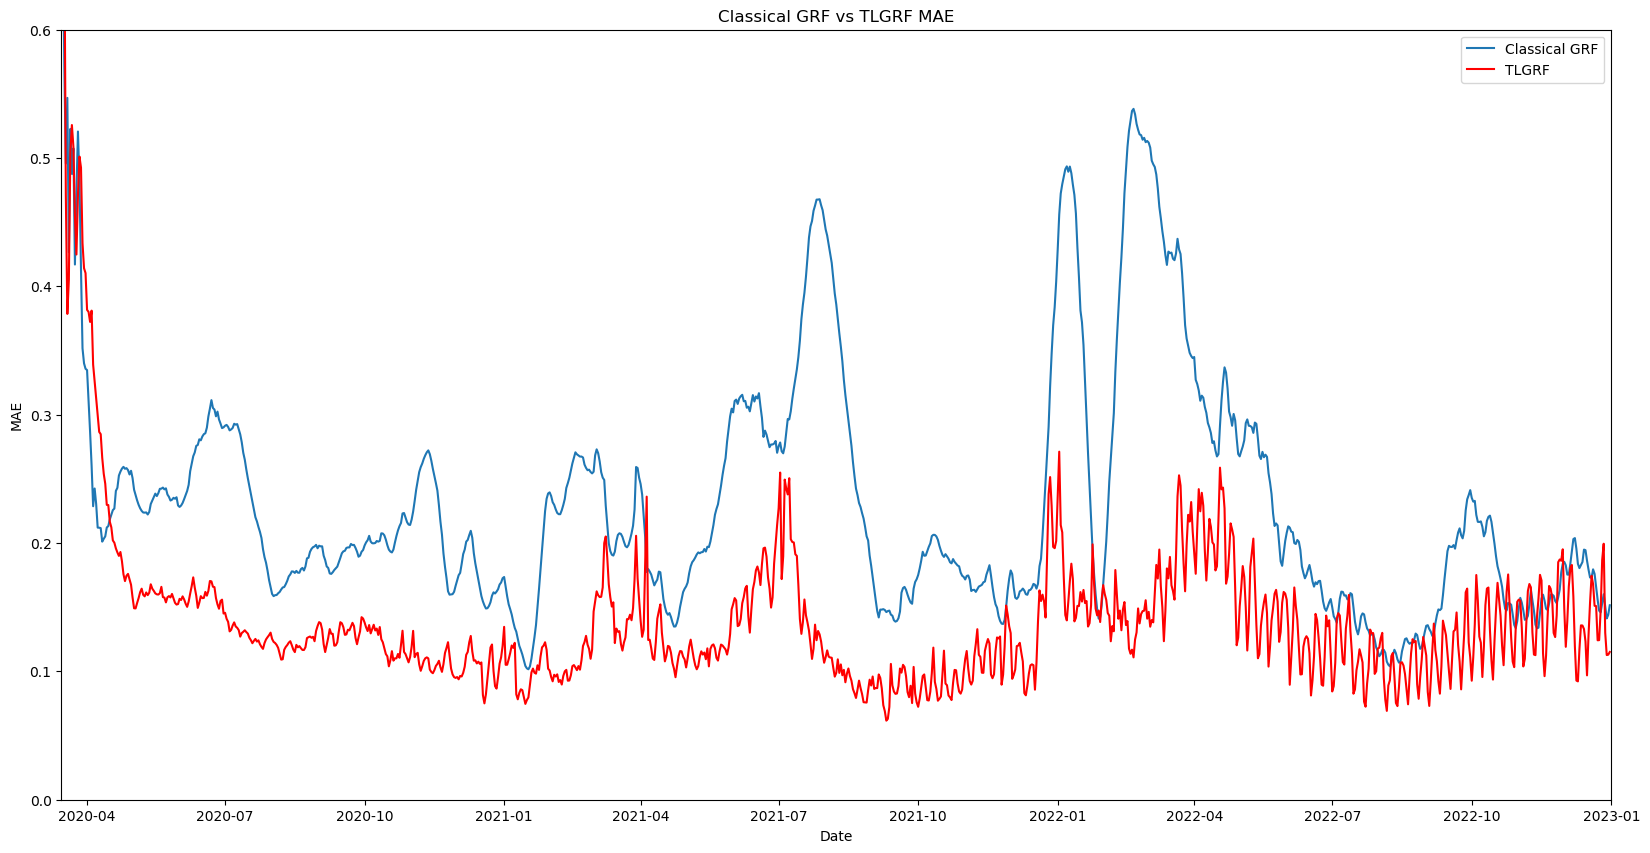

In [21]:
plot_classical_vs_TLGRF("MAE")

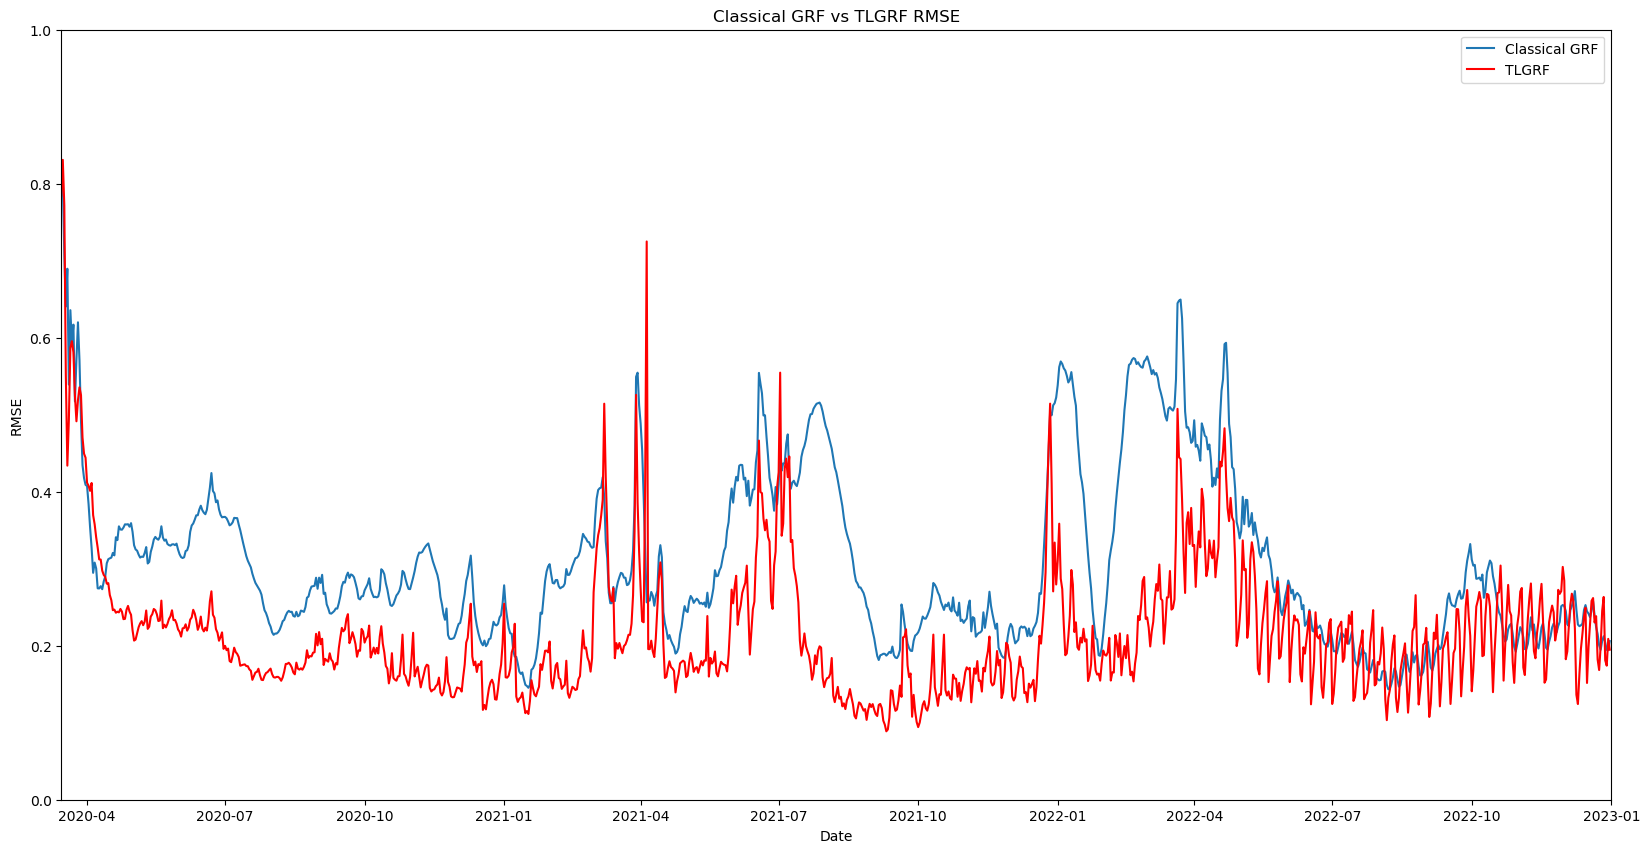

In [22]:
plot_classical_vs_TLGRF("RMSE")

In [23]:
def plot_triple(metric="MAE"):

    triple_fig_path = os.path.join("presentation_{}_classical_vs_invariant_vs_TLGRF.png".format(metric))
    ylim_max_list = {"MAE": 0.6, "RMSE": 1.0}
    plt.figure(figsize=(20,10))

    #plt.plot(tcv_performance_df["mae"], label="tcv")
    #plt.plot(ctcv_performance_df["mae"], label="ctcv")
    #plt.plot(MAE_shifted_W_time_invariant_GRF_df, label="Time Invariant Shifted W GRF")
    #plt.plot(MAE_shifted_W_time_variant_GRF_df, label="Time Variant Shifted W GRF")
    plt.plot(combined_daily_metrics_df["{} Time Variant GRF".format(metric)], label="Classical GRF")
    plt.plot(combined_daily_metrics_df["{} Time Invariant GRF".format(metric)], label="Classical GRF with Time-invariant Features")
    plt.plot(combined_daily_metrics_df["{} TLGRF".format(metric)], label="TLGRF", color="r")

    plt.legend()
    plt.xlabel("Date")
    plt.ylabel("{}".format(metric))
    plt.title("Classical GRF vs Classical GRF with Time-invariant Features vs TLGRF {}".format(metric))
    plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
    plt.ylim(0,ylim_max_list[metric])
    plt.savefig(triple_fig_path)

    plt.show()

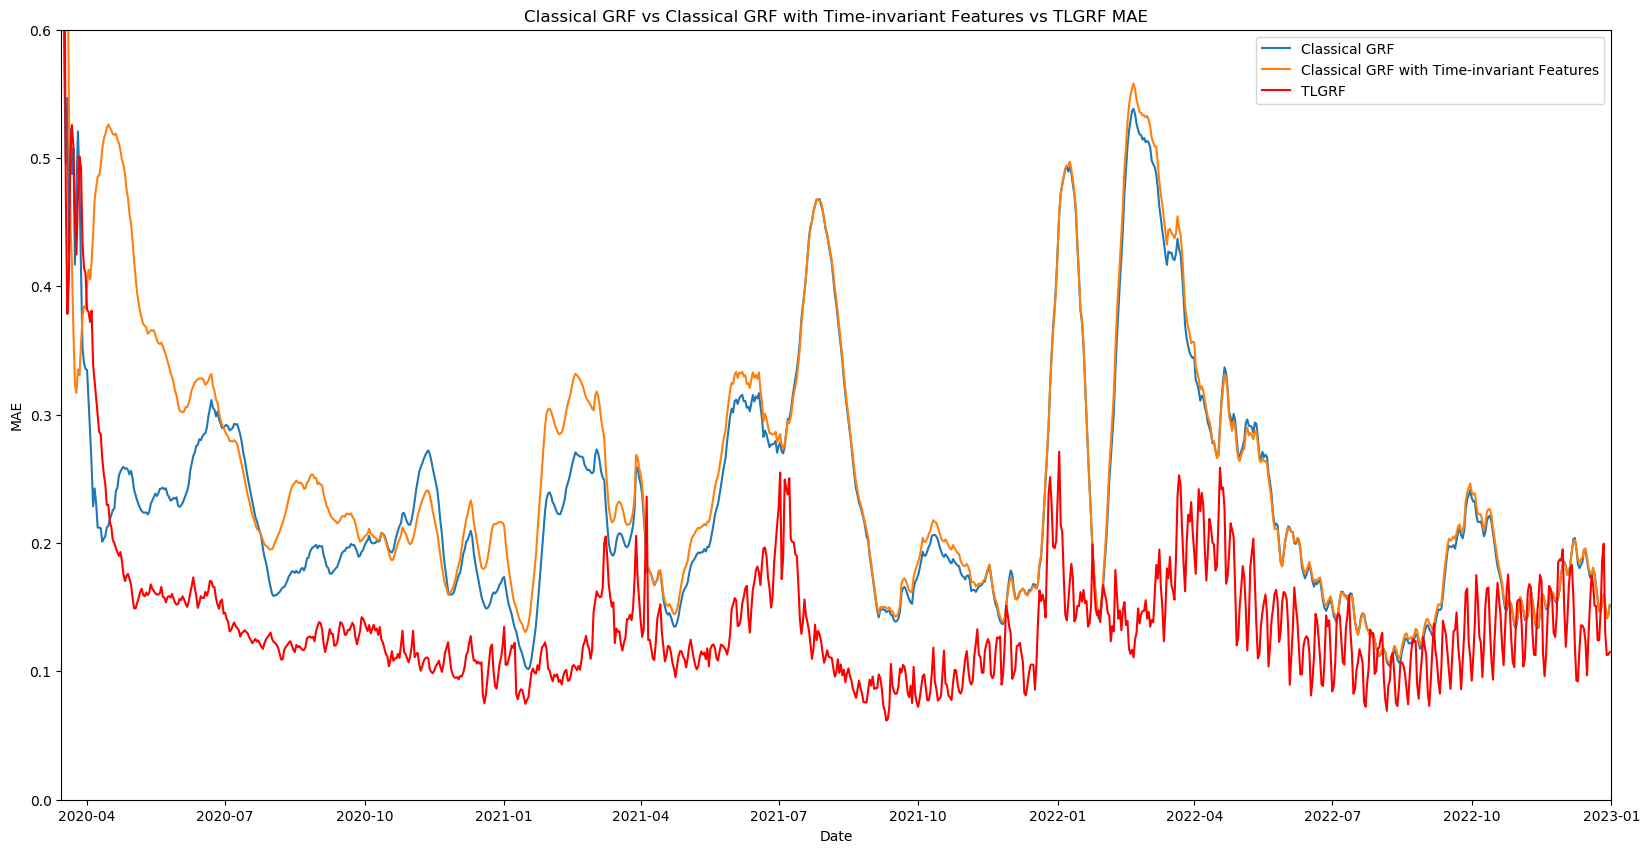

In [24]:
plot_triple("MAE")

In [ ]:
plot_triple("RMSE")